Import bibliotek

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.float_format', '{:,.2f}'.format)

Załadowanie danych

In [2]:
df = pd.read_csv("sales_random.csv")

In [3]:
df.head()

,sale_rcn_id,name,amount,amount_sqm,floor_number,rooms_number,type,currency,size,creation_date,invest_name,invest_city
0,245750,146517_8.0502.245_BUD.127_LOK,"752,024.00","15,788.87",6,2,mieszkalna,PLN,47.63,2025-04-16,Ulica Instalatorów 7A,Warszawa
1,245746,146517_8.0502.245_BUD.68_LOK,"545,000.00","14,379.95",2,2,mieszkalna,PLN,37.90,2025-04-16,Ulica Instalatorów 7A,Warszawa
2,245751,146517_8.0502.245_BUD.94_LOK,"657,359.50","17,163.43",7,2,mieszkalna,PLN,38.30,2025-04-16,Ulica Instalatorów 7A,Warszawa
3,242913,146517_8.0826.117_BUD.58_LOK,"855,942.85","14,306.25",3,3,mieszkalna,PLN,59.83,2025-04-16,Aleje Jerozolimskie 190,Warszawa
4,241286,146514_8.1145.111_BUD.82_LOK,"598,424.89","11,521.46",3,3,mieszkalna,PLN,51.94,2025-04-16,Ulica Mieczysława Pożaryskiego 35A,Warszawa


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sale_rcn_id    2500 non-null   int64  
 1   name           2500 non-null   object 
 2   amount         2500 non-null   float64
 3   amount_sqm     2500 non-null   float64
 4   floor_number   2500 non-null   int64  
 5   rooms_number   2500 non-null   int64  
 6   type           2500 non-null   object 
 7   currency       2500 non-null   object 
 8   size           2500 non-null   float64
 9   creation_date  2500 non-null   object 
 10  invest_name    2500 non-null   object 
 11  invest_city    2500 non-null   object 
dtypes: float64(3), int64(3), object(6)
memory usage: 234.5+ KB


In [5]:
df['type'].value_counts()

type
mieszkalna    2500
Name: count, dtype: int64

In [6]:
df['creation_date'].min()


'2016-12-08'

In [7]:
df['creation_date'].max()

'2025-10-15'

In [8]:
df.describe()

,sale_rcn_id,amount,amount_sqm,floor_number,rooms_number,size
count,"2,500.00","2,500.00","2,500.00","2,500.00","2,500.00","2,500.00"
mean,"156,672.83","1,881,912.15","28,384.37",3.94,2.74,57.59
std,"55,702.61","11,836,597.84","168,256.96",2.59,1.20,25.68
min,"52,087.00","35,000.00",528.94,0.00,0.00,20.13
25%,"110,919.00","409,341.95","8,319.80",2.00,2.00,40.60
50%,"160,508.00","565,000.00","10,680.33",3.00,3.00,51.01
75%,"201,987.25","769,000.00","14,138.56",5.00,3.00,67.70
max,"259,752.00","183,982,922.19","3,001,352.73",30.00,10.00,247.54


In [9]:
df[df['amount_sqm']==df['amount_sqm'].max()]

,sale_rcn_id,name,amount,amount_sqm,floor_number,rooms_number,type,currency,size,creation_date,invest_name,invest_city
823,86541,146510_8.0308.41.2_BUD.122_LOK,"183,982,922.19","3,001,352.73",13,2,mieszkalna,PLN,61.30,2017-07-21,Ulica Złota 44,Warszawa


In [10]:
df[df['amount']==df['amount'].max()]

,sale_rcn_id,name,amount,amount_sqm,floor_number,rooms_number,type,currency,size,creation_date,invest_name,invest_city
822,86545,146510_8.0308.41.2_BUD.121_LOK,"183,982,922.19","861,343.27",13,4,mieszkalna,PLN,213.60,2017-07-21,Ulica Złota 44,Warszawa
823,86541,146510_8.0308.41.2_BUD.122_LOK,"183,982,922.19","3,001,352.73",13,2,mieszkalna,PLN,61.30,2017-07-21,Ulica Złota 44,Warszawa
824,86542,146510_8.0308.41.2_BUD.123_LOK,"183,982,922.19","2,996,464.53",13,2,mieszkalna,PLN,61.40,2017-07-21,Ulica Złota 44,Warszawa


In [11]:
df[df['size']==df['size'].max()]

,sale_rcn_id,name,amount,amount_sqm,floor_number,rooms_number,type,currency,size,creation_date,invest_name,invest_city
273,55884,146510_8.0603.21/4.2_BUD.10_LOK,"10,200,000.00","41,205.46",5,3,mieszkalna,PLN,247.54,2018-10-15,Ulica Wioślarska 10,Warszawa


In [12]:
kolumny = ['amount','amount_sqm','size']
for i in kolumny:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1

    df = df[(df[i] >= Q1 - 1.5*IQR) & (df[i] <= Q3 + 1.5*IQR)]

df = df = df[df['rooms_number'] != 0]

In [13]:
df.describe()

,sale_rcn_id,amount,amount_sqm,floor_number,rooms_number,size
count,"2,124.00","2,124.00","2,124.00","2,124.00","2,124.00","2,124.00"
mean,"154,965.14","561,612.45","11,004.22",3.92,2.74,52.25
std,"56,137.79","229,449.76","3,658.16",2.50,0.92,16.69
min,"52,087.00","35,000.00",528.94,0.00,1.00,20.13
25%,"108,880.75","387,000.00","8,154.73",2.00,2.00,39.59
50%,"157,492.50","521,338.17","10,304.64",3.50,3.00,48.94
75%,"200,563.00","690,000.00","13,363.61",5.00,3.00,63.15
max,"259,752.00","1,306,962.44","21,303.60",17.00,7.00,102.20


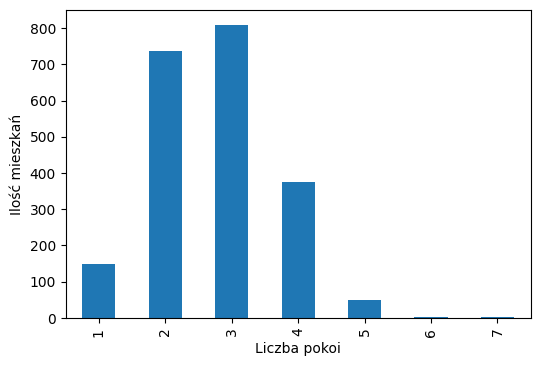

rooms_number
3    810
2    738
4    375
1    149
5     48
6      3
7      1
Name: count, dtype: int64

In [14]:
df['rooms_number'].value_counts().sort_index().plot(kind='bar', figsize=(6,4))
plt.xlabel('Liczba pokoi')
plt.ylabel('Ilość mieszkań')
plt.show()
df["rooms_number"].value_counts()

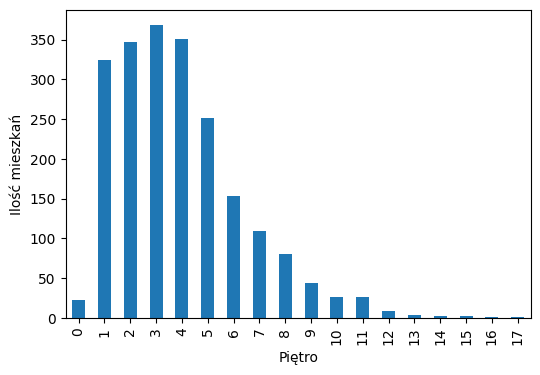

floor_number
3     369
4     351
2     347
1     324
5     251
6     153
7     110
8      80
9      44
10     27
11     26
0      22
12      9
13      4
15      3
14      2
16      1
17      1
Name: count, dtype: int64

In [15]:
df['floor_number'].value_counts().sort_index().plot(kind='bar', figsize=(6,4))
plt.xlabel('Piętro')
plt.ylabel('Ilość mieszkań')
plt.show()
df["floor_number"].value_counts()

Text(0.5, 1.0, 'Rozkład rozmiaru mieszkań')

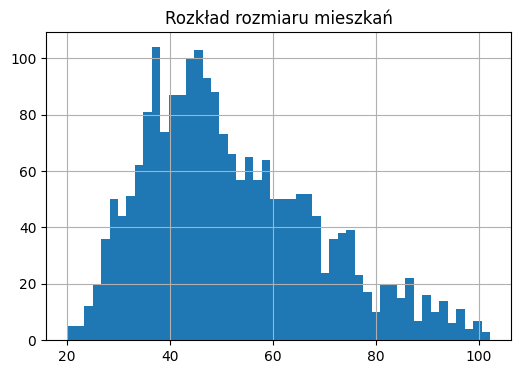

In [16]:
plt.figure(figsize=(6,4))
df["size"].hist(bins=50)
plt.title('Rozkład rozmiaru mieszkań')

Text(0.5, 1.0, 'Rozkład ceny za m2')

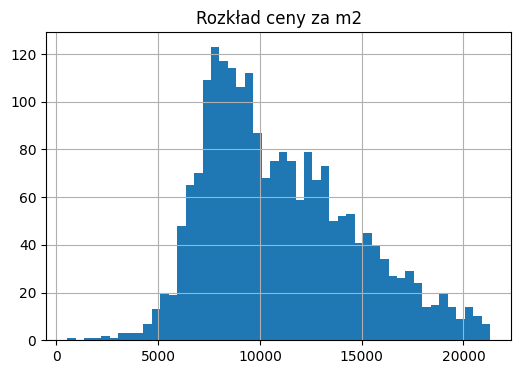

In [17]:
plt.figure(figsize=(6,4))
df["amount_sqm"].hist(bins=50)
plt.title('Rozkład ceny za m2')

In [18]:
gb = df.groupby('rooms_number')['size'].mean()
print(gb)
gb = df.groupby('rooms_number')['amount_sqm'].mean()
print(gb)
gb = df.groupby('floor_number')['amount_sqm'].mean()
print(gb)


rooms_number
1   31.94
2   41.47
3   55.66
4   70.13
5   82.23
6   70.83
7   67.40
Name: size, dtype: float64
rooms_number
1   12,380.67
2   11,751.64
3   10,631.50
4    9,976.21
5    9,820.38
6    9,014.75
7    4,525.22
Name: amount_sqm, dtype: float64
floor_number
0     9,001.06
1    10,619.15
2    10,771.36
3    10,975.23
4    11,127.44
5    11,205.70
6    11,381.19
7    11,369.22
8    11,176.02
9    11,120.25
10   11,663.67
11   11,385.65
12   12,761.29
13   13,574.73
14   10,321.70
15    9,456.35
16   13,242.20
17   10,795.55
Name: amount_sqm, dtype: float64


!Mała liczba obserwacji w mieszkaniach 6 i 7 osobowych oraz wysokich pięter

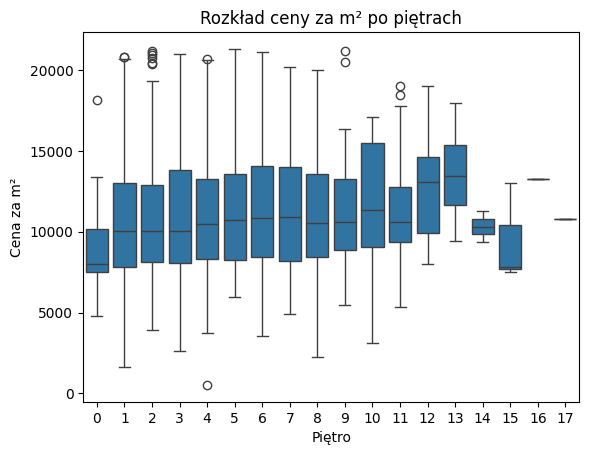

In [19]:
sns.boxplot(x='floor_number', y='amount_sqm', data=df)
plt.xlabel('Piętro')
plt.ylabel('Cena za m²')
plt.title('Rozkład ceny za m² po piętrach')
plt.show()

Text(0.5, 1.0, 'Sprzedaż w czasie')

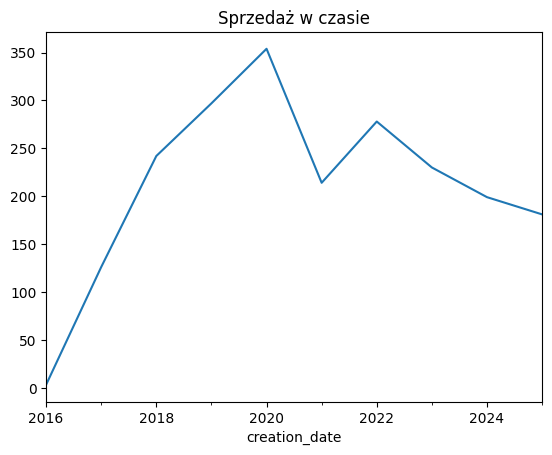

In [20]:
df['creation_date'] = pd.to_datetime(df['creation_date'])
df.groupby(df['creation_date'].dt.to_period('Y')).size().plot()
plt.title('Sprzedaż w czasie')

In [21]:
df['month'] = df['creation_date'].dt.month
df['year'] = df['creation_date'].dt.year
monthly_counts = df.groupby(['year','month']).size()

# Sortowanie po wartościach (malejąco)
monthly_counts_sorted = monthly_counts.sort_values(ascending=False).head(100)

print(monthly_counts_sorted)

year  month
2020  12       92
2023  11       77
2018  7        75
2022  3        74
2019  2        72
               ..
2017  12        1
2022  12        1
2018  8         1
      5         1
2023  9         1
Length: 93, dtype: int64


<Axes: xlabel='creation_date'>

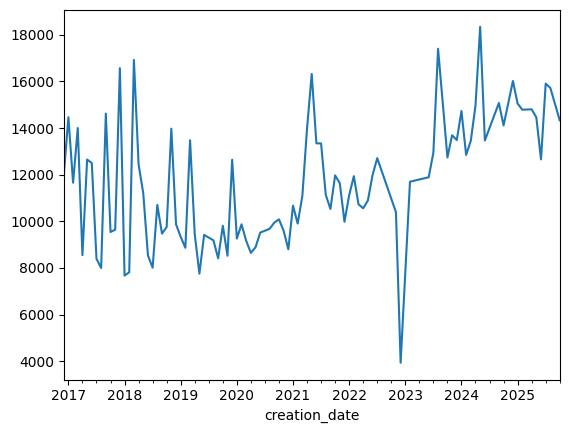

In [22]:
df.groupby(df['creation_date'].dt.to_period('M'))['amount_sqm'].mean().plot()

<Axes: xlabel='creation_date'>

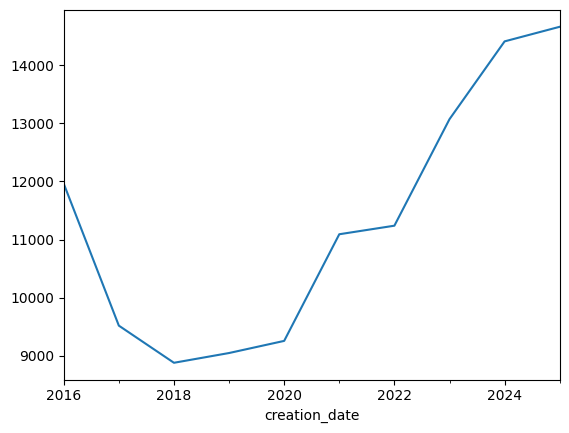

In [23]:
df.groupby(df['creation_date'].dt.to_period('Y'))['amount_sqm'].mean().plot()

In [24]:
monthly_avg = df.groupby(df['creation_date'].dt.to_period('M'))['amount_sqm'].mean()
monthly_avg_sorted = monthly_avg.sort_values(ascending=False)  # malejąco
print(monthly_avg_sorted)

creation_date
2024-05   18,343.20
2023-08   17,401.13
2018-03   16,921.33
2017-12   16,567.48
2021-05   16,319.94
             ...   
2017-08    7,996.81
2018-02    7,813.06
2019-05    7,751.86
2018-01    7,671.22
2022-12    3,930.92
Freq: M, Name: amount_sqm, Length: 93, dtype: float64


In [25]:
df[(df['year']==2022) & (df['month']==12)]

,sale_rcn_id,name,amount,amount_sqm,floor_number,rooms_number,type,currency,size,creation_date,invest_name,invest_city,month,year
1155,189956,146507_8.0104.37.1_BUD.1_LOK,"207,159.56","3,930.92",2,2,mieszkalna,PLN,52.70,2022-12-30,Ulica Saska 111C,Warszawa,12,2022


!Tylko jedna obserwacja z 12-2022 & niska wartość metra

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2124 entries, 0 to 2499
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   sale_rcn_id    2124 non-null   int64         
 1   name           2124 non-null   object        
 2   amount         2124 non-null   float64       
 3   amount_sqm     2124 non-null   float64       
 4   floor_number   2124 non-null   int64         
 5   rooms_number   2124 non-null   int64         
 6   type           2124 non-null   object        
 7   currency       2124 non-null   object        
 8   size           2124 non-null   float64       
 9   creation_date  2124 non-null   datetime64[ns]
 10  invest_name    2124 non-null   object        
 11  invest_city    2124 non-null   object        
 12  month          2124 non-null   int32         
 13  year           2124 non-null   int32         
dtypes: datetime64[ns](1), float64(3), int32(2), int64(3), object(5)
memory usage:

In [43]:
cpi = pd.read_csv("inflacja_prepared.csv", index_col=0).reset_index(drop=True)

In [38]:
cpi.head()

,Rok,Miesiąc,Wartość,date
0,2025,1,4.90,2025-01-01
1,2025,2,4.90,2025-02-01
2,2025,3,4.90,2025-03-01
3,2025,4,4.30,2025-04-01
4,2025,5,4.00,2025-05-01


In [44]:
dfp = df.merge(
    cpi[["Rok", "Miesiąc", "Wartość"]],
    left_on=["year", "month"],
    right_on=["Rok", "Miesiąc"],
    how="left"
).drop(columns=["Rok", "Miesiąc"])

In [45]:
dfp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2124 entries, 0 to 2123
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   sale_rcn_id    2124 non-null   int64         
 1   name           2124 non-null   object        
 2   amount         2124 non-null   float64       
 3   amount_sqm     2124 non-null   float64       
 4   floor_number   2124 non-null   int64         
 5   rooms_number   2124 non-null   int64         
 6   type           2124 non-null   object        
 7   currency       2124 non-null   object        
 8   size           2124 non-null   float64       
 9   creation_date  2124 non-null   datetime64[ns]
 10  invest_name    2124 non-null   object        
 11  invest_city    2124 non-null   object        
 12  month          2124 non-null   int32         
 13  year           2124 non-null   int32         
 14  Wartość        2124 non-null   float64       
dtypes: datetime64[ns](1),

In [46]:
dfp = dfp[['amount','amount_sqm','floor_number','rooms_number','size','month','year','Wartość']]

In [47]:
dfp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2124 entries, 0 to 2123
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   amount        2124 non-null   float64
 1   amount_sqm    2124 non-null   float64
 2   floor_number  2124 non-null   int64  
 3   rooms_number  2124 non-null   int64  
 4   size          2124 non-null   float64
 5   month         2124 non-null   int32  
 6   year          2124 non-null   int32  
 7   Wartość       2124 non-null   float64
dtypes: float64(4), int32(2), int64(2)
memory usage: 116.3 KB


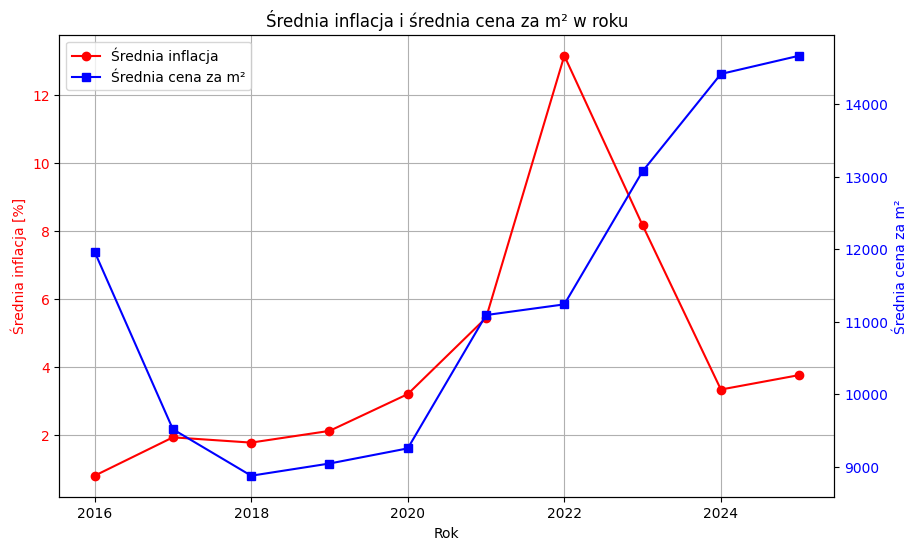

In [50]:
# Grupowanie po roku i liczenie średnich
yearly = dfp.groupby("year").agg({
    "Wartość": "mean",      # średnia inflacja
    "amount_sqm": "mean"    # średnia cena za m2
}).reset_index()

# Tworzymy wykres z podwójną osią Y
fig, ax1 = plt.subplots(figsize=(10,6))

# Linia średniej inflacji
color = 'red'
ax1.set_xlabel('Rok')
ax1.set_ylabel('Średnia inflacja [%]', color=color)
ax1.plot(yearly['year'], yearly['Wartość'], color=color, marker='o', label='Średnia inflacja')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

# Druga oś Y dla średniej ceny za m²
ax2 = ax1.twinx()
color = 'blue'
ax2.set_ylabel('Średnia cena za m²', color=color)
ax2.plot(yearly['year'], yearly['amount_sqm'], color=color, marker='s', label='Średnia cena za m²')
ax2.tick_params(axis='y', labelcolor=color)

# Dodanie legendy
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('Średnia inflacja i średnia cena za m² w roku')
plt.show()

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [59]:
X = dfp.drop(columns=['amount'])
y = dfp['amount']

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=40)


In [72]:
lin = LinearRegression()
rf = RandomForestRegressor(n_estimators=100,random_state=40)

In [74]:
models = [("Linear Regression", lin), ("Random Forest", rf)]

In [ ]:
# Tworzymy modele
lin = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=40)

models = [("Linear Regression", lin), ("Random Forest", rf)]
for name, model in models:
    model.fit(X_train, y_train)
    
for name, model in models:
    
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)
    
    rmse_train = mean_squared_error(y_train, y_pred_train, squared=False)
    rmse_test  = mean_squared_error(y_test, y_pred_test, squared=False)
    
    r2_train = r2_score(y_train, y_pred_train)
    r2_test  = r2_score(y_test, y_pred_test)
    
    print(f"=== {name} ===")
    print(f"Train RMSE: {rmse_train:.2f}, R²: {r2_train:.4f}")
    print(f"Test  RMSE: {rmse_test:.2f}, R²: {r2_test:.4f}\n")

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


=== Linear Regression ===
Train RMSE: 57349.24, R²: 0.9390
Test  RMSE: 51666.12, R²: 0.9435

=== Random Forest ===
Train RMSE: 6203.95, R²: 0.9993
Test  RMSE: 12961.16, R²: 0.9964



C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


!Kontynuacja...